# Описание задачи:
* **Предметная область**: Рекоммендация музыки.
* **Источник данных**: [Датасет с kaggle
](https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs).
* **Цель исследования**: Построить модель, которая на основе предпочтений будет предлагать похожие треки.
* **Среда разработки**: Google Colab - специальзированная среда разработки для Python

# Описание исходных данных:
* **track_id**: Id для трека.
* **track_name**: Название трека.
* **track_artist**: Имя артиста.
* **track_popularity**: Популярность трека [0;100].
* **track_album_id**: Id Альбома трека.
* **track_album_name**: Название албьома трека.
* **track_album_release_date**: Дата выпуска албома трека.
* **playlist_name**: Название плейлистаа в котором находится трек.
* **playlist_id**: Id плейлиста.
* **playlist_genre**: Жанр плейлиста.
* **playlist_subgenre**: Поджанр плейлиста.
* **danceability**: Танцевальность трека. Описывает насколько трек подходит для танцевания основываясь на ритме, темпе, закономерность трека и т.д. [0;1].
* **energy**: Энергия трека. Описывает интенсивность и активность трека. Обычно энергичные треки - это про громкость и шумность. [0;1].
* **key**: Общая тональность трека. 0 = C, 1 = C#/Db, 2 = D, и т.д. если тональность неизвестна: -1.
* **loudness**: Средняя громкость трека в dB.
* **mode**: Гамма трека. 0 = минор, 1 = мажор.
* speechiness: Определяет насколько треке часто произносятся слова. [0;1]
* **acousticness**: Насколько трек акустичный [0;1]
* **instrumentalness**: Описывает насколько трек инструментальный. Насколько в треке меньше голоса [0;1]
* **liveness**: Определяет насколько трек был записан вживую [0;1]
* **valence**: Определяет музыкальную позитивность трека. Чем ближе значение к нулю тем больше трек депрессивный или злой. [0;1]
* **tempo**: BPM трека - кол-во ударов в минуту.
* **duration_ms**: Длительность трека в милисекундах.

# Импорт библиотек
* **pandas**: Библиотека для загрузки и обработки данных.
* **numpy**: Библиотека для математических и матричных операций. В случае этой работы в библотеке использовались только математические функции.
* **matplotlib**, **seaborn**, **plotly**: Библиотеки для визуализации данных
* **warnings**: Встроенный модуль Python. Используется для управления предупреждениями.
* **scikit-learn**: Библиотека для построения и оценки моделей машинного обучения.

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
from sklearn.metrics import pairwise_distances, silhouette_score, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
warnings.filterwarnings("ignore")

# 1)

# Загрузка датасета

In [101]:
df = pd.read_csv('/content/spotify_songs.csv')
df

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


# 2, 3)

# Заполнение пропусков и переопределения типа у признаков

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

* Как мы можем заметить пропущенные значения в колонках имеются в: **track_name**, **track_artist**, **track_album_name**, **duration_ms**.
* Так как пропущенных значений мало, я решил просто удалить строки с Nan значениями.
* В целом все признаки имеют свой тип, но переведем **track_album_release_date** в тип **datetime** и создадим 4 новых признака: **track_release_year**, **track_release_month**, **track_release_day**, **track_release_weekday**.

In [103]:
df_filtered = df.copy()
df_filtered['track_album_release_date'] = pd.to_datetime(df_filtered['track_album_release_date'], errors='coerce')
df_filtered = df_filtered.dropna()
df_filtered['track_release_year'] = df_filtered['track_album_release_date'].dt.year
df_filtered['track_release_month'] = df_filtered['track_album_release_date'].dt.month
df_filtered['track_release_day'] = df_filtered['track_album_release_date'].dt.day
df_filtered['track_release_weekday'] = df_filtered['track_album_release_date'].dt.weekday

In [104]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30942 entries, 0 to 32832
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   track_id                  30942 non-null  object        
 1   track_name                30942 non-null  object        
 2   track_artist              30942 non-null  object        
 3   track_popularity          30942 non-null  int64         
 4   track_album_id            30942 non-null  object        
 5   track_album_name          30942 non-null  object        
 6   track_album_release_date  30942 non-null  datetime64[ns]
 7   playlist_name             30942 non-null  object        
 8   playlist_id               30942 non-null  object        
 9   playlist_genre            30942 non-null  object        
 10  playlist_subgenre         30942 non-null  object        
 11  danceability              30942 non-null  float64       
 12  energy                 

# 4)

# Вопросы для тренировки фильтрации данных:

1.   Названия треков с валентностью >= 0.99
2.   Названия треков с громкостью > 0 (dB)





In [105]:
print('--------- Треки с высокой валентностью ----------')
print(df_filtered[df_filtered['valence'] >= 0.99][['track_name', 'track_artist']])

print('\n--------- Названия треков с очень высокой громкостью ----------')
print(df_filtered[df_filtered['loudness'] > 0.9][['track_name', 'track_artist']])

--------- Треки с высокой валентностью ----------
      track_name track_artist
13531  Low Rider          War
22762  Low Rider          War

--------- Названия треков с очень высокой громкостью ----------
                           track_name track_artist
12197        Raw Power - Iggy Pop Mix  The Stooges
27716  Escape From Love - Curbi Remix   Eva Simons


# 5)

# Вопросы для тренировки агрегации данных:

1.   Сколько всего треков с danceability > 0.7 у которых тональность мажорная и сколько треков danceability > 0.7 с минорной тональностью
2.   Какая средняя популярность у треков с energy > 0.7 и c energy < 0.7

In [106]:
print('--------- Танцевальность к тональности ----------')
print(f"danceability > 0.7 и мажорная тональность: {df_filtered[df_filtered['danceability'] > 0.7]['mode'].value_counts()[0]}")
print(f"danceability > 0.7 и минорная тональность: {df_filtered[df_filtered['danceability'] > 0.7]['mode'].value_counts()[1]}")

print('\n--------- Популярность к энергии ----------')
print(f"популярность energy > 0.7: {df_filtered[df_filtered['energy'] > 0.7]['track_popularity'].mean()}")
print(f"популярность energy < 0.7: {df_filtered[df_filtered['energy'] < 0.7]['track_popularity'].mean()}")

--------- Танцевальность к тональности ----------
danceability > 0.7 и мажорная тональность: 6016
danceability > 0.7 и минорная тональность: 7035

--------- Популярность к энергии ----------
популярность energy > 0.7: 40.623705819350235
популярность energy < 0.7: 45.26278722344739


# 6)

# Вопросы для тренировки нахождения максимальных, минимальных данных:

1.   У какого трека самый максимальный BPM
2.   Какой самый короткий трек

In [107]:
print('--------- Трек с максимальным BPM ----------')
print(df_filtered[df_filtered['tempo'] == df_filtered['tempo'].max()][['track_name', 'track_artist']])

print('\n--------- Самый короткий трек ----------')
print(df_filtered[df_filtered['duration_ms'] == df_filtered['duration_ms'].min()][['track_name', 'track_artist']])

--------- Трек с максимальным BPM ----------
                                         track_name    track_artist
20021  Dope's Gotta Hold On Me (feat. Ese Rich Roc)  Spanish F.L.Y.

--------- Самый короткий трек ----------
                  track_name      track_artist
11363  Hi, How're You Doin'?  DREAMS COME TRUE


# 7)

# Табличная диаграмма: кол-во плейлистов по жанрам.

In [108]:
genre_count = df_filtered['playlist_genre'].value_counts().reset_index()
genre_count.columns = ['playlist_genre', 'count']
px.bar(genre_count, x='playlist_genre', y='count', title='Кол-во плейлистов по жанрам')

# 8)

# Круговая диаграмма: % треков по ключу'

In [109]:
px.pie(df_filtered, names='key', title='% треков по ключу')

# 9)

# Вопросы для тренировки агренации данных:

1.   средний, максимальный и минимальный speechiness по жанру
2.   средний, максимальный и минимальный loudness по жанру

In [110]:
print('--------- Speechiness ----------')
print(df_filtered.groupby('playlist_genre').agg({'speechiness': ['mean', 'max', 'min']}))

print('\n--------- Acousticness ----------')
print(df_filtered.groupby('playlist_genre').agg({'loudness': ['mean', 'max', 'min']}))

--------- Speechiness ----------
               speechiness               
                      mean    max     min
playlist_genre                           
edm               0.086872  0.624  0.0239
latin             0.103271  0.662  0.0232
pop               0.074824  0.869  0.0228
r&b               0.118902  0.918  0.0224
rap               0.196095  0.877  0.0243
rock              0.058656  0.488  0.0000

--------- Acousticness ----------
                loudness               
                    mean    max     min
playlist_genre                         
edm            -5.411837  1.135 -19.563
latin          -6.222085 -0.046 -46.448
pop            -6.300329 -0.700 -26.279
r&b            -7.807318 -0.478 -34.283
rap            -7.013916  0.642 -26.207
rock           -7.410332  1.275 -26.087


# 10)

# Формулировка нового признака
Сформулируем новый признак **key_mode**, который будет отвечать за тональность трека: c Minor, C Major, c# minor, C# Major и т.д.

In [111]:
key_mapping = {
    0: 'C',
    1: 'C#',
    2: 'D',
    3: 'D#',
    4: 'E',
    5: 'F',
    6: 'F#',
    7: 'G',
    8: 'G#',
    9: 'A',
    10: 'A#',
    11: 'B'
}

mode_mapping = {
    1: 'major',
    0: 'minor'
}

df_filtered['key_mode'] = df_filtered['key'].map(key_mapping) + ' ' + df_filtered['mode'].map(mode_mapping)

print(df_filtered['key_mode'].value_counts())


key_mode
C# major    2516
C major     2365
G major     2186
D major     2045
B minor     1753
G# major    1547
F minor     1501
A major     1486
F# minor    1402
A# minor    1396
A minor     1320
C# minor    1317
E minor     1276
F# major    1134
B major     1076
F major     1056
G minor      889
C minor      881
E major      785
G# minor     776
A# major     767
D minor      587
D# minor     487
D# major     394
Name: count, dtype: int64


In [112]:
key_popularity = df_filtered.groupby('key_mode', as_index=False)['track_popularity'].mean()
px.bar(key_popularity, x='key_mode', y='track_popularity')

# 11)

# Точечная диаграмма для численных признаков
По диаграмме можно заметить, что в основном признаки не имеют между собой сильной кореляции.

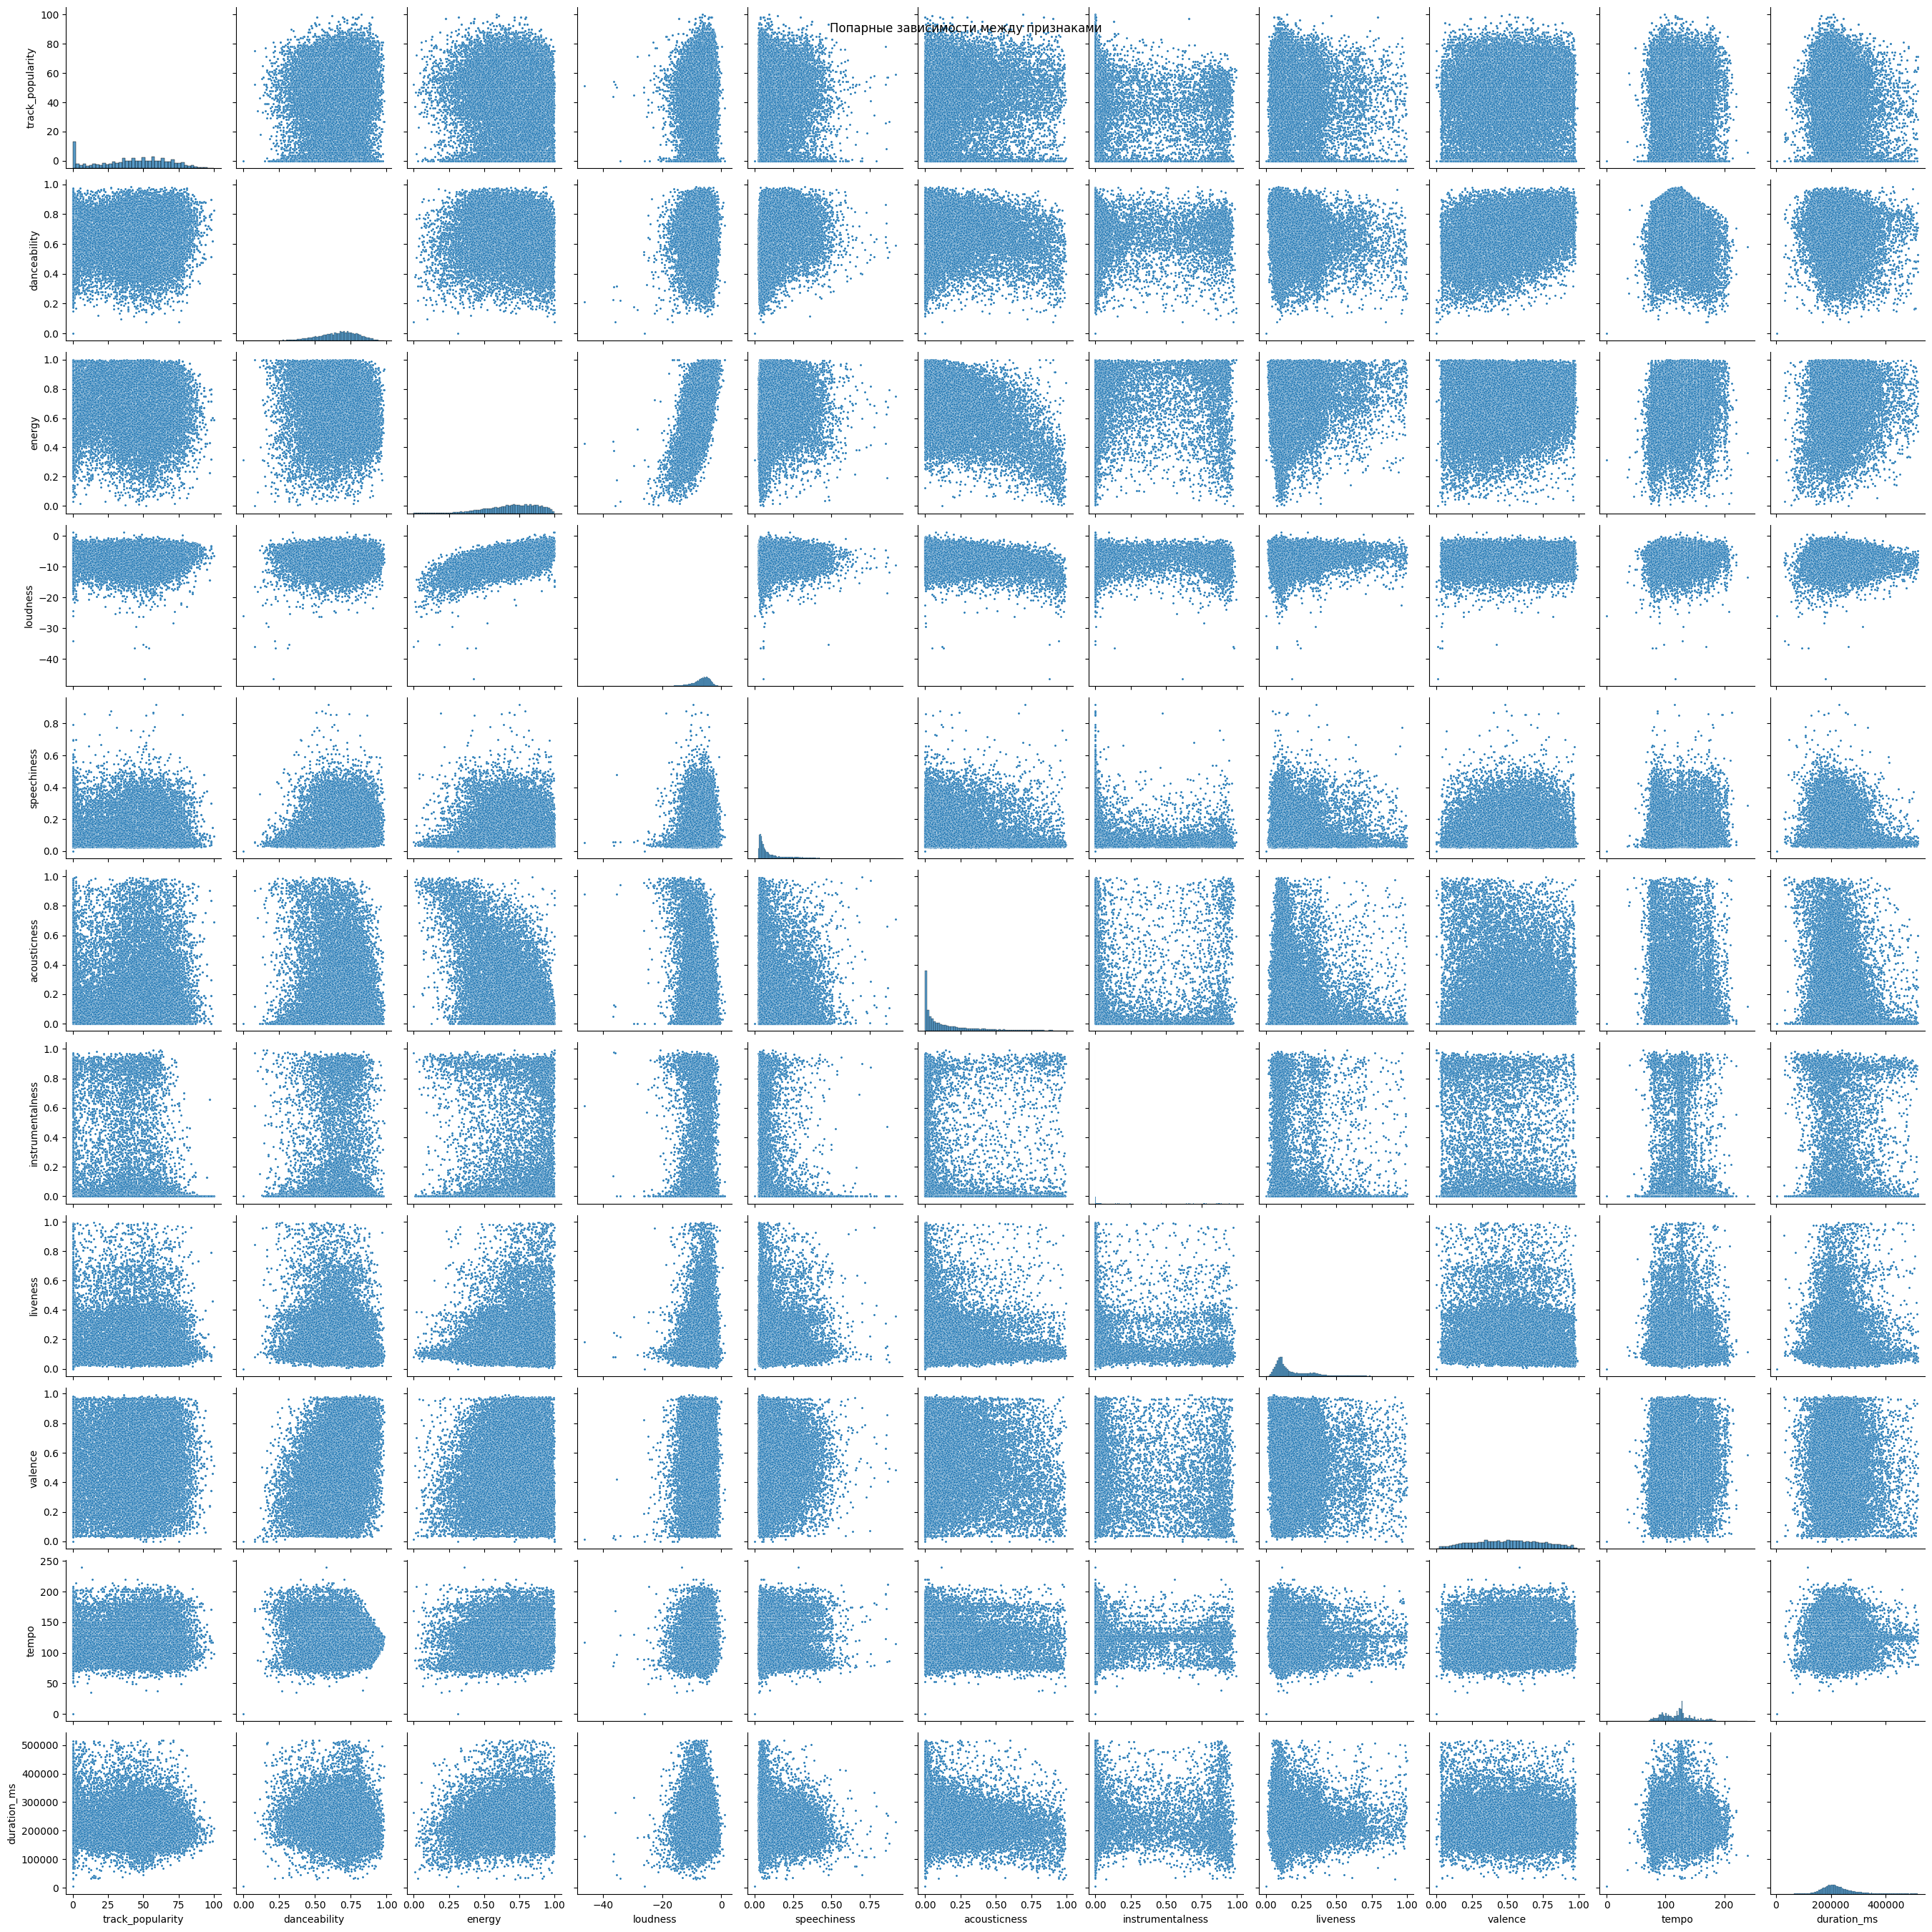

In [113]:
num_features = ['track_popularity', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
sns.pairplot(df_filtered, vars=num_features, plot_kws={'s': 5})
plt.suptitle('Попарные зависимости между признаками')
plt.show()


# 12)

# Боксплот для численных признаков
Можно заметить, что большинство признаков имеют достаточно много выбросов.


# Полученные инсайты
* Можно заметить, что имеется **мода на танцевальные энергичины, громкие треки**.
* Так-же имеется **мода на электронные инструментальные треки без голоса**. Об это говорят малые значения признаков: **speechiness**, **instrumentalness**, **liveness**.


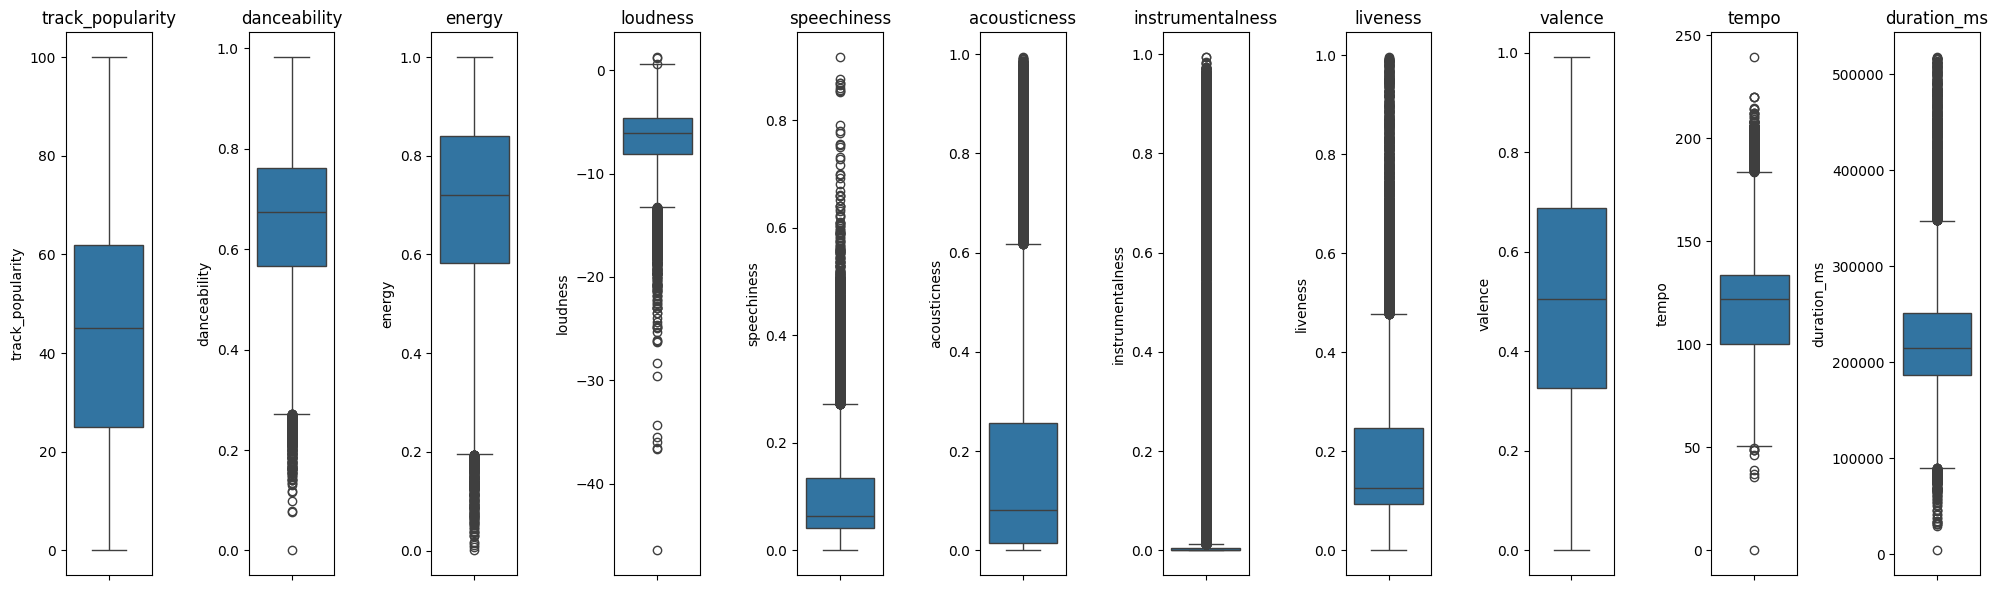

In [114]:
plt.figure(figsize=(20, 6))
for i, feature in enumerate(num_features, 1):
    plt.subplot(1, len(num_features), i)
    sns.boxplot(y=df_filtered[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()


Удаляем выбросы

In [115]:
Q1 = df_filtered[num_features].quantile(0.25)
Q3 = df_filtered[num_features].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_filtered_clean = df_filtered[~((df_filtered[num_features] < lower_bound) | (df_filtered[num_features] > upper_bound)).any(axis=1)]

Боксплот числовых признаков без выбросов

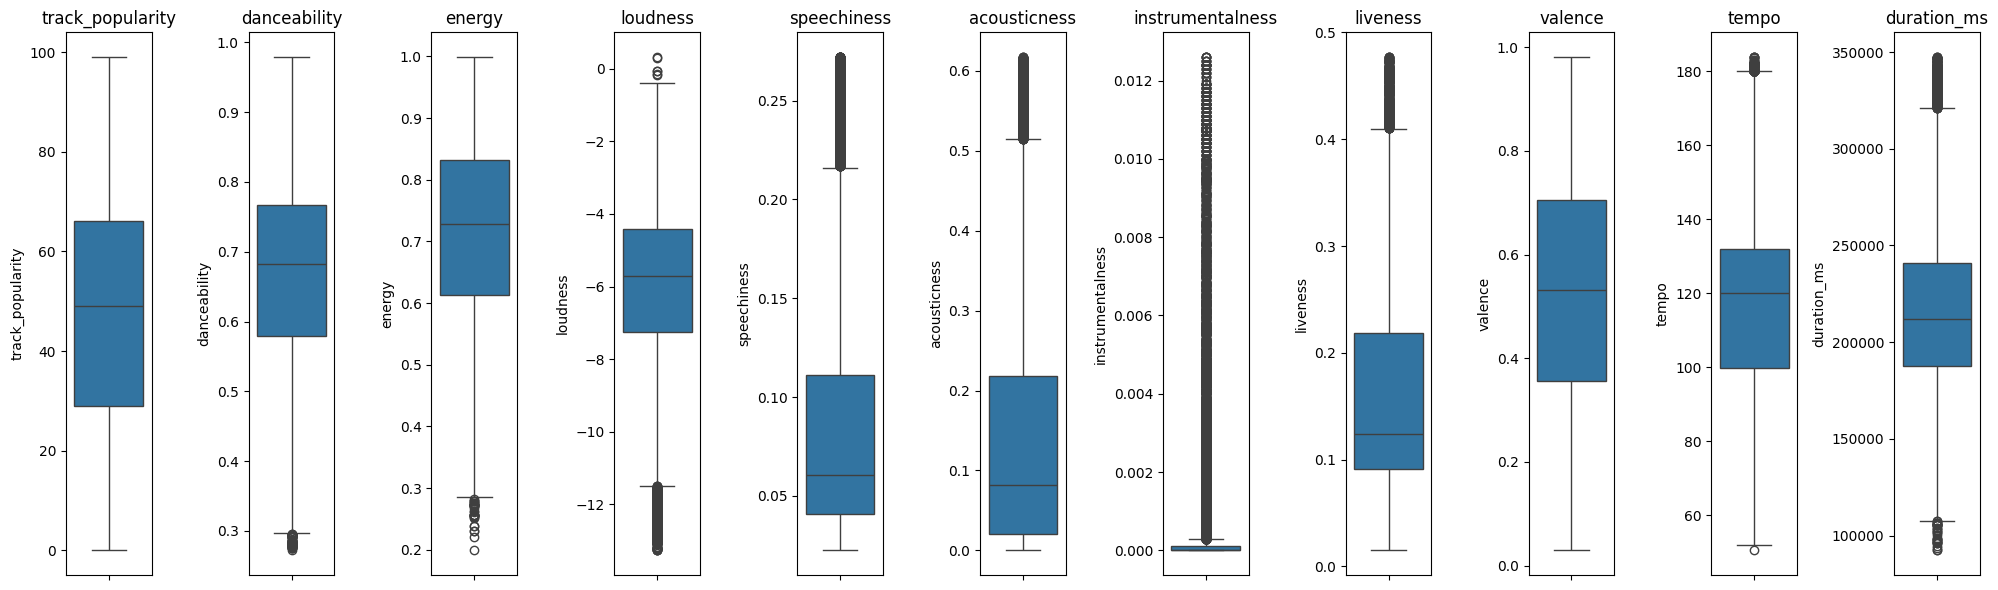

In [116]:
plt.figure(figsize=(20, 6))
for i, feature in enumerate(num_features, 1):
    plt.subplot(1, len(num_features), i)
    sns.boxplot(y=df_filtered_clean[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()


# 13)

# Модель которую будем использовать (KMeans)

* **Кластеризация** - это метод, который группирует объекты (в нашем случае треки).
* **Почему именно кластеризация**: Если два объекта попали в один класте - значит, они похожи. А если пользователю нравится что-то из этого кластера, вероятно, понравится и другое из него.
* **Но** например если-бы у нас был признак рейтинга треков от пользователей, мы бы могли использовать регрессию.
* Я буду использовать модель **K-Means**. K-Means - разделяет данные на k кластеров так, чтобы объекты кластера были как можно ближе к его центру.

# 15)

# Кодирование признаков
* При кодировании признаков я пытался усидеть на двух стульях: мне нужно было чтобы модель могла работать с категориальными данными, не создавая много новых признаков. А все потому что разреженность данных при кластеризации - это проблема. Алгоритм начинает терять смысл различия между объектами.
* Признак **key_mode** оказался лишним шумом, так что его пришлось убрать.
* **track_release_year** я разделил на десятелетия.
* **track_release_day** я разделил на начало, середину и конец месяца.
* **track_release_month** я разделил на сезоны.
* Для **playlist_genre**, **track_release_weekday**, **month_period**, **season** я использовал one-hot кодирование, так как уникальных категорий в этих признаков не много, что не сильно скажется на разреженности данных.
* Для **playlist_subgenre**  использовал частотное кодирование.
* Удалил **track_release_day**, **track_release_month**, **playlist_subgenre** так как они не помогут нам в предсказании.

In [117]:
df_filtered_clean_final = df_filtered_clean.copy().drop(['key_mode'], axis=1)

df_filtered_clean_final['release_decade'] = (df_filtered_clean_final['track_release_year'] // 10) * 10

df_filtered_clean_final['month_period'] = pd.cut(df_filtered_clean_final['track_release_day'], bins=[0, 10, 20, 31], labels=['start', 'middle', 'end'], right=False)

def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'
df_filtered_clean_final['season'] = df_filtered_clean_final['track_release_month'].apply(get_season)

df_filtered_clean_final = pd.get_dummies(df_filtered_clean_final, columns=['playlist_genre', 'track_release_weekday', 'month_period', 'season'])

subgenre_counts = df_filtered_clean_final['playlist_subgenre'].value_counts(normalize=True)
df_filtered_clean_final['playlist_subgenre_encoded'] = df_filtered_clean_final['playlist_subgenre'].map(subgenre_counts)

df_filtered_clean_final = df_filtered_clean_final.drop(['track_release_day', 'track_release_month', 'playlist_subgenre'], axis=1)

df_filtered_clean_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18128 entries, 0 to 32830
Data columns (total 44 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   track_id                   18128 non-null  object        
 1   track_name                 18128 non-null  object        
 2   track_artist               18128 non-null  object        
 3   track_popularity           18128 non-null  int64         
 4   track_album_id             18128 non-null  object        
 5   track_album_name           18128 non-null  object        
 6   track_album_release_date   18128 non-null  datetime64[ns]
 7   playlist_name              18128 non-null  object        
 8   playlist_id                18128 non-null  object        
 9   danceability               18128 non-null  float64       
 10  energy                     18128 non-null  float64       
 11  key                        18128 non-null  int64         
 12  loudness 

# 16)

# Нормализация признаков
Простандартизировал количественные признаки, используя **StandardScaler**. Для **KMeans** важно, чтобы все признаки имели одинаковый масштаб - поэтому я использовал, именно этот метод для нормализации

In [118]:
scaler = StandardScaler()
numeric_cols = df_filtered_clean_final.select_dtypes(include=['number']).columns
df_filtered_clean_final[numeric_cols] = scaler.fit_transform(df_filtered_clean_final[numeric_cols])

In [119]:
df_filtered_clean_final.describe()

,track_popularity,track_album_release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_release_year,release_decade,playlist_subgenre_encoded
count,1.812800e+04,18128,1.812800e+04,1.812800e+04,1.812800e+04,1.812800e+04,1.812800e+04,1.812800e+04,1.812800e+04,1.812800e+04,1.812800e+04,1.812800e+04,1.812800e+04,1.812800e+04,1.812800e+04,1.812800e+04,1.812800e+04
mean,-3.135670e-17,2013-01-12 02:20:12.180052736,-7.839174e-17,-5.330638e-16,2.508536e-17,-2.822103e-16,-5.487422e-17,-1.066128e-16,-6.898473e-17,4.703504e-17,-2.680998e-16,-4.013657e-16,-2.351752e-16,9.407009e-18,6.359138e-15,2.746847e-15,-3.762804e-17
min,-1.830197e+00,1957-01-01 00:00:00,-2.965477e+00,-3.442812e+00,-1.481119e+00,-3.268865e+00,-1.147853e+00,-1.028266e+00,-9.231042e-01,-3.395239e-01,-1.485597e+00,-2.243396e+00,-2.779671e+00,-2.936686e+00,-5.591230e+00,-6.107041e+00,-2.039376e+00
25%,-6.711175e-01,2011-01-01 00:00:00,-6.721381e-01,-6.794534e-01,-9.268878e-01,-5.614683e-01,-1.147853e+00,-7.276304e-01,-7.910578e-01,-3.395239e-01,-7.216966e-01,-7.759489e-01,-7.826091e-01,-6.847938e-01,-1.550856e-01,4.132746e-01,-4.403475e-01
50%,1.282477e-01,2017-04-07 00:00:00,1.047586e-01,9.482105e-02,1.815742e-01,1.378170e-01,8.711919e-01,-4.092155e-01,-3.919633e-01,-3.385033e-01,-3.943108e-01,7.465501e-03,3.496028e-02,-1.142449e-01,4.489304e-01,4.132746e-01,1.585818e-01
75%,8.077081e-01,2019-05-31 00:00:00,7.322521e-01,7.823233e-01,7.358052e-01,7.122700e-01,8.711919e-01,4.037932e-01,4.881159e-01,-2.776559e-01,5.568102e-01,7.819265e-01,5.156489e-01,5.754791e-01,6.502690e-01,4.132746e-01,3.789425e-01
max,2.126661e+00,2020-01-29 00:00:00,2.315926e+00,1.897012e+00,1.567152e+00,2.848588e+00,8.711919e-01,3.006067e+00,3.071063e+00,6.323179e+00,3.139855e+00,2.017483e+00,2.620099e+00,3.087177e+00,7.509383e-01,1.499994e+00,1.831064e+00
std,1.000028e+00,NaN,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00


# 17)

# Раздедение на обучающую и тестовую выборку

In [120]:
train_data, test_data = train_test_split(df_filtered_clean_final, test_size=0.25, random_state=42)

print("Viewing training x_train", train_data.shape)
print("Viewing test test_data", test_data.shape)

Viewing training x_train (13596, 44)
Viewing test test_data (4532, 44)


# 14)

# Формулировка факторных признаков

In [121]:
X = df_filtered_clean_final.drop(['playlist_id', 'track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id'], axis=1)

# 20)

# Подбор гиперпараметра для KMeans
Для подбора оптимального **K** для **KMeans** я использовал **метод локтя**. Суть метода - при увеличении кластеров **k**, внутрикластерная ошибка **SSE** (Sum of Squared Errors) уменьшается, но начиная с некоторого момента - сильное улучшения прекращается. Изгиб на графике, напоминающий локоть - и есть оптимальное кол-во кластеров

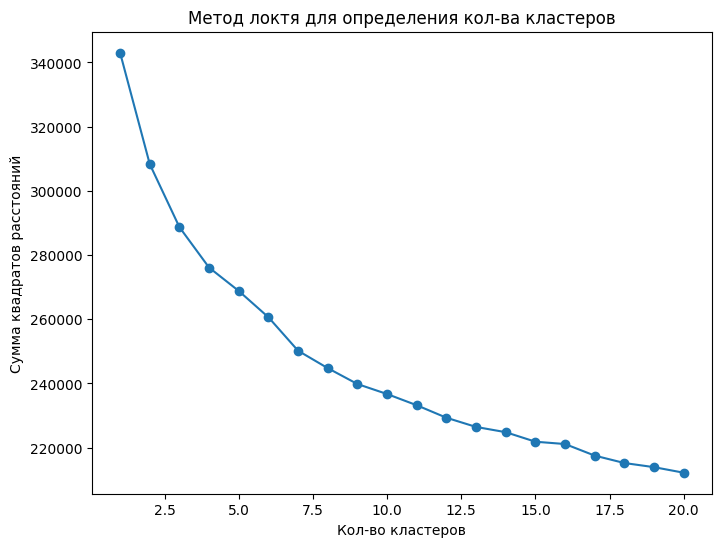

In [122]:
sse = []
k_range = range(1, 21)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Кол-во кластеров')
plt.ylabel('Сумма квадратов расстояний')
plt.title('Метод локтя для определения кол-ва кластеров')
plt.grid(False)
plt.show()

# 18)

# Обучение KMeans модели с оптимальным гиппермараметром

In [123]:
kmeans = KMeans(n_clusters=9, random_state=42)
df_filtered_clean_final['cluster_kmeans'] = kmeans.fit_predict(X)
df_filtered_clean_final['cluster_kmeans'].unique()

array([4, 1, 0, 6, 7, 5, 8, 3, 2], dtype=int32)

# График соотношений кластеров для KMeans модели

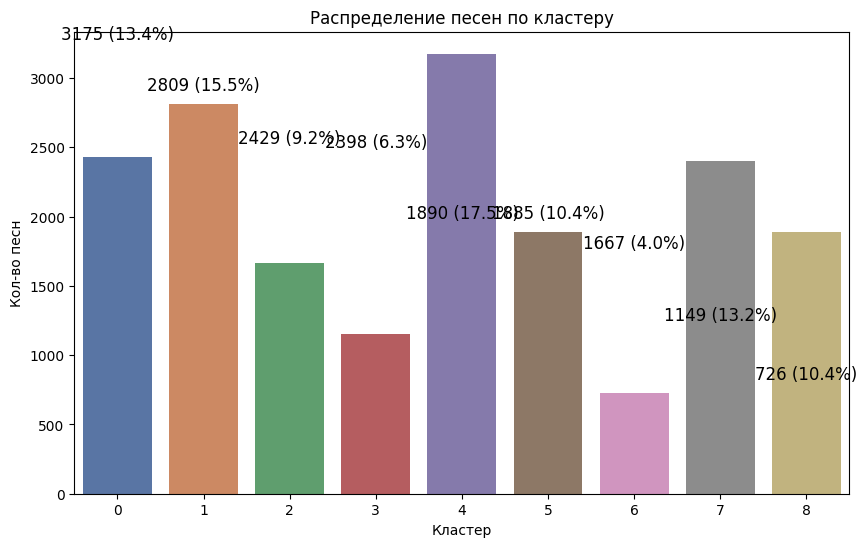

In [124]:
cluster_counts = df_filtered_clean_final['cluster_kmeans'].value_counts().sort_values(ascending=False)

total_songs = cluster_counts.sum()
cluster_percentages = (cluster_counts / total_songs) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='deep')
plt.xlabel('Кластер')
plt.ylabel('Кол-во песн')
plt.title('Распределение песен по кластеру')

for index, value in enumerate(cluster_counts):
    plt.text(index, value + 100, f'{value} ({cluster_percentages[index]:.1f}%)', ha='center', fontsize=12)

plt.grid(False)
plt.show()

# 19)

# Ошибка KMeans

In [125]:
sulhoette = silhouette_score(X, df_filtered_clean_final['cluster_kmeans'])
print(f"Ошибка silhouette: {sulhoette}")

davies = davies_bouldin_score(X, df_filtered_clean_final['cluster_kmeans'])
print(f"Ошибка Davies: {davies}")

Ошибка silhouette: 0.06122401409505237
Ошибка Davies: 2.6177710265705123


Низкая ошибка Silhouette и высокая Davies-Bouldin говорит о слабой, размазанной кластеризации.

# Визуализация кластеров для KMeans
Для визуализации использую метод **PCA** (Метод главных компонент) - это метод снижения размерности, для возможности визуализации.

In [126]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
pca

PCA(n_components=2)

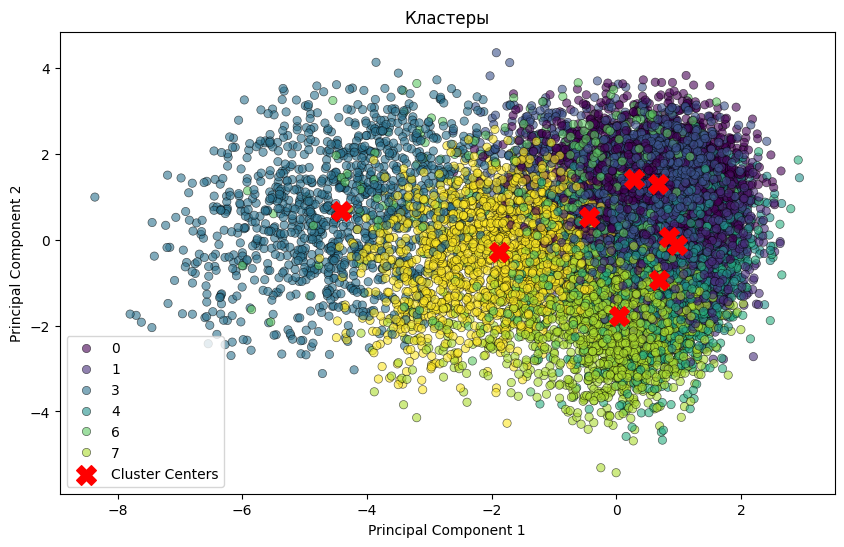

In [127]:
kmeans = KMeans(n_clusters=9, random_state=42)
clusters = kmeans.fit_predict(X)
df_filtered_clean_final['cluster_kmeans'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0],
                y=X_pca[:, 1],
                hue=df_filtered_clean_final['cluster_kmeans'],
                palette='viridis',
                alpha=0.6,
                edgecolor='k')

centers = kmeans.cluster_centers_

centers_pca = pca.transform(centers)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='red',
            s=200,
            marker='X',
            label='Cluster Centers')

plt.title('Кластеры')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(False)
plt.show()

# Предсказание KMeans

In [128]:
def recommend_songs_by_cluster_kmeans(song_name, data):
    selected_song = df_filtered_clean_final[df_filtered_clean_final['track_name'].str.contains(song_name, case=False, na=False)]

    if selected_song.empty:
        print("Song not found.")
        return None

    cluster = selected_song['cluster_kmeans'].values[0]

    recommended_songs = df_filtered_clean_final[df_filtered_clean_final['cluster_kmeans'] == cluster]

    recommended_songs = recommended_songs[recommended_songs['track_name'] != selected_song['track_name'].values[0]]

    return recommended_songs[['track_name', 'track_artist']].head(30)

In [129]:
song_name = "Shape of You"
top_recommendations_kmeans = recommend_songs_by_cluster_kmeans(song_name, df_filtered_clean_final)

if top_recommendations_kmeans is not None:
    print("Recommended music")
    print(top_recommendations_kmeans)

Recommended music
                                            track_name        track_artist
2                      All the Time - Don Diablo Remix        Zara Larsson
13      SOS - Laidback Luke Tribute Remix / Radio Edit              Avicii
14   Summer Days (feat. Macklemore & Patrick Stump ...       Martin Garrix
16                  All My Friends - Eden Prince Remix         AJ Mitchell
17   Say My Name (feat. Bebe Rexha & J Balvin) - Lu...        David Guetta
22   Don't Leave Me Alone (feat. Anne-Marie) - EDX'...        David Guetta
26                   One Thing Right - Firebeatz Remix          Marshmello
31                           Signs - Eden Prince Remix             Starley
37                 Side Effects - Fedde Le Grand Remix    The Chainsmokers
39             Paradise - Bazzi vs. Black Caviar Remix           Bazzi vs.
42                                          Unlove You    Armin van Buuren
46   When It Comes To You - Benny Benassi & BB Team...           Sean Paul
48     

# 19)

# Оценка KMeans кластеризации

In [130]:
silhouette = silhouette_score(X, df_filtered_clean_final['cluster_kmeans'])
calinski = calinski_harabasz_score(X, df_filtered_clean_final['cluster_kmeans'])
davies = davies_bouldin_score(X, df_filtered_clean_final['cluster_kmeans'])

print(f"Silhouette Score: {silhouette:.3f}")
print(f"Calinski–Harabasz Index: {calinski:.3f}")
print(f"Davies–Bouldin Index: {davies:.3f}")

Silhouette Score: 0.061
Calinski–Harabasz Index: 974.765
Davies–Bouldin Index: 2.618


# Вывод для KMeans
Хорошо прокластеризировать музыку основываясь только на метриках аудио-фич довольно затруднительно. Данные признаки не дают нам четкой группировки, потому что похожие песни могут звучать по разному. В целом музыка субъективна.

# 18)

# Вторая модель которую будем использовать (NearestNeighbors)
* KMeans заставляет каждый трек принадлежать к какому-то кластеру, даже если треки сильно различаются.
* NN просто ищет похожие треки без жесткой группировки. Это особенно полезно для такой сферы как музыка, где сферы похожести сильно размыты.

# 20)

# Нахождение лучшего гиперпараметра K для NN
Создадим матрицу взаимодействия для системы рекомендаций.

In [131]:
interaction_matrix = train_data.pivot_table(index='playlist_id', columns='track_id', values='track_popularity').fillna(0)
interaction_matrix

track_id,0017A6SJgTbfQVU2EtsPNo,008rk8F6ZxspZT4bUlkIQG,00EPIEnX1JFjff8sC6bccd,00GfGwzlSB8DoA0cDP2Eit,00Gu3RMpDW2vO9PjlMVFDL,00GxbkrW4m1Tac5xySEJ4M,00MI0oGDVJYM1qWbyUOIhH,00NAQYOP4AmWR549nnYJZu,00PTJgyN0GTk2ProuLJ1aW,00ReeHCY0FQUyuAUyPJdnk,...,7zoaxuyAARzX2SqkiHQQqD,7zqjvrNUtLn5wHym65HuA0,7zrXS0Mp9h3KynGEx50TP4,7zs5zHtydDQ4RTEylVtXRp,7zsXy7vlHdItvUSH8EwQss,7ztN8tfXYaC8LBRyLZJLA1,7zxLkZbUxITHabPzGN8Xgc,7zyLObYw4QUKQDyZOb4J0Y,7zycSpvjDcqh6YT1FEl2kY,7zzZmpw8L66ZPjH1M6qmOs
playlist_id,,,,,,,,,,,,,,,,,,,,,
0275i1VNfBnsNbPl0QIBpG,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
03qQtbNHoJuFezRu2CnLuF,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
03sDEv7FN58Mb9CJOs1Tgn,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
06zrBJ5cts5aemZmqe80J7,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
07SNJ4MwYba9wwmzrbjmYi,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7sq6nuruoMyDhEWkX2oYOg,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7tkgK1tm9hYkWp7EFyOcAr,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7vJOXFe40axY7qS39vGDyH,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


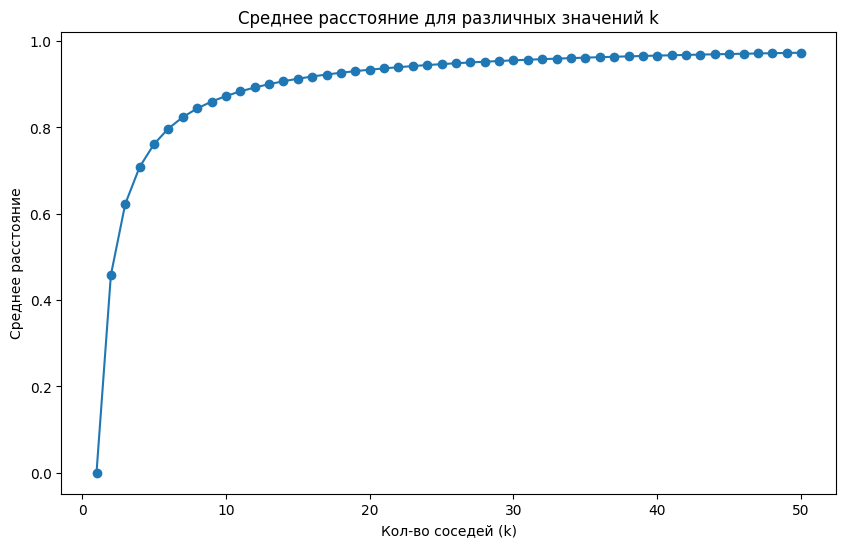

In [132]:
k_values = list(range(1, 51))

results = []

for k in k_values:
    model = NearestNeighbors(n_neighbors=k, metric='cosine')
    model.fit(interaction_matrix)

    distances, indices = model.kneighbors(interaction_matrix)

    mean_distance = np.mean(distances)
    results.append((k, mean_distance))

ks, scores = zip(*results)
plt.figure(figsize=(10, 6))
plt.plot(ks, scores, marker='o')
plt.title('Среднее расстояние для различных значений k')
plt.xlabel('Кол-во соседей (k)')
plt.ylabel('Среднее расстояние')
plt.grid(False)
plt.show()

Оптимальный k по методу колена k=8

# 18)


# Обучение NN модели

In [133]:
model = NearestNeighbors(n_neighbors=8, metric='cosine')
model.fit(interaction_matrix)

NearestNeighbors(metric='cosine', n_neighbors=8)

# Предсказания NN модели

In [134]:
default_song_name = "Shape of You"

def recommend_songs(df, model, interaction_matrix, song_name=default_song_name, k=8):
    song_playlists = df[df['track_name'].str.contains(song_name, case=False, na=False)]['playlist_id'].unique()

    if len(song_playlists) == 0:
        print("Песня не найдена в датасете.")
        return

    playlist_id = song_playlists[0]

    unique_playlists = df['playlist_id'].unique()

    if playlist_id not in unique_playlists:
        print("Идентификатор плейлиста не найден в уникальных плейлистах.")
        return

    playlist_index = np.where(unique_playlists == playlist_id)[0][0]

    try:
        if isinstance(interaction_matrix, pd.DataFrame):
            distances, indices = model.kneighbors(interaction_matrix.iloc[playlist_index].values.reshape(1, -1), n_neighbors=k+1)
        else:
            distances, indices = model.kneighbors(interaction_matrix[playlist_index].reshape(1, -1), n_neighbors=k+1)
    except IndexError:
        print("Индекс плейлиста выходит за пределы матрицы взаимодействия.")
        return

    similar_playlists = indices.flatten()[1:]

    original_playlist_tracks = set(df[df['playlist_id'] == playlist_id]['track_id'])
    recommended_tracks = set()

    for idx in similar_playlists:
        similar_playlist_id = unique_playlists[idx]
        similar_playlist_tracks = set(df[df['playlist_id'] == similar_playlist_id]['track_id'])
        recommended_tracks.update(similar_playlist_tracks - original_playlist_tracks)

    if recommended_tracks:
        recommended_tracks_info = df[df['track_id'].isin(recommended_tracks)][['track_name', 'track_artist']].drop_duplicates()
        print("Рекоммендованные песни:")
        print(recommended_tracks_info)
    else:
        print("Нет песен для рекоммендаций.")

print(default_song_name)
recommend_songs(df_filtered_clean_final, model, interaction_matrix)

Shape of You
Рекоммендованные песни:
                                              track_name track_artist
1888                                         Basket Case    Green Day
1943                                       Thunderstruck        AC/DC
3628                                  Livin' On A Prayer     Bon Jovi
3715                                              Raging         Kygo
3749                                         Tropic Love     Diviners
...                                                  ...          ...
31756                                          Hell Yeah       Tujamo
31758                             Supermash - Radio Edit     Rudeejay
31759                       With U (feat. Karen Harding)       Tujamo
31764                     Wildcard (feat. Sidnie Tipton)        KSHMR
31768  Delirious (Boneless) (feat. Kid Ink) - Chris L...   Steve Aoki

[280 rows x 2 columns]


# 19)

# Оценка NN модели

In [135]:
def evaluate_model(model, interaction_matrix, test_tracks, k):
    hits = 0
    total = 0

    unique_playlists = list(interaction_matrix.index)

    for playlist_id, test_set in test_tracks.items():
        if playlist_id not in unique_playlists:
            continue

        idx = unique_playlists.index(playlist_id)
        distances, indices = model.kneighbors(
            interaction_matrix.iloc[idx].values.reshape(1, -1), n_neighbors=k+1
            )
        similar_playlists = indices.flatten()[1:]

        recommended_tracks = set()
        for sim_idx in similar_playlists:
            sim_playlist_id = unique_playlists[sim_idx]
            sim_playlist_tracks = set(train_tracks.get(sim_playlist_id, []))
            recommended_tracks.update(sim_playlist_tracks)

        hits += len(set(test_set) & recommended_tracks)
        total += len(test_set)

    hit_rate = hits / total if total > 0 else 0
    print(f"Hit Rate@{k}: {hit_rate:.3f}")

In [136]:
train_tracks = {}
test_tracks = {}

for playlist_id, group in df_filtered_clean_final.groupby('playlist_id'):
    tracks = group['track_id'].tolist()
    if len(tracks) < 2:
        continue
    train, test = train_test_split(tracks, test_size=0.2, random_state=42)
    train_tracks[playlist_id] = train
    test_tracks[playlist_id] = test

train_data = []
for pid, tracks in train_tracks.items():
    for t in tracks:
        train_data.append({'playlist_id': pid, 'track_id': t, 'track_popularity': 1})

train_df = pd.DataFrame(train_data)
interaction_matrix_train = train_df.pivot_table(
    index='playlist_id', columns='track_id', values='track_popularity', fill_value=0
)

model = NearestNeighbors(n_neighbors=8, metric='cosine')
model.fit(interaction_matrix_train)

evaluate_model(model, interaction_matrix_train, test_tracks, k=8)


Hit Rate@8: 0.119


Hit Rate оценка - сколько раз модель попала в "нужный трек", получилась довольно малая.

# Вывод для NearestNeighbors

Мы подвердили вывод для модели KMeans. Матрицы взаимодействий обычно очень разрежены (боьшинство пользователей взаимодействует лишь с малым процентом треков). При поиске ближайших соседей сложно найти два вектора, которые будут сильно пересекаться, чтобы измерить их сходство.

# Общий вывод

Рекоммендация треков - это не простая задача, которая требует не тривиальных подходов. Рекоммендации, основанные на анализе аудиосигналов и рекоммендации с использованием матрицы взаимодействий плохо предсказывают предпочтения пользователей. Но могут хорошо работать вместе, при достаточных больших данных. Такой подход называется гибридная система рекоммендаций, который используют стриминговые сервисы. Что довольно интересная тема, но трудно реализуемая в рамках студенченского проекта.